In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('/Users/devammpatel/Desktop/ EDA & FE on Netflix Dataset /Dataset/Netflix_rawdata.csv')
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 1.6 MB


In [4]:
df['director'].value_counts()

director
Not Given                  2588
Rajiv Chilaka                20
Raúl Campos, Jan Suter       18
Alastair Fothergill          18
Suhas Kadav                  16
                           ... 
Mu Chu                        1
Chandra Prakash Dwivedi       1
Majid Al Ansari               1
Peter Hewitt                  1
Mozez Singh                   1
Name: count, Length: 4528, dtype: int64

Hence many shows are with unknown director names, let's see it by plotting pie chart

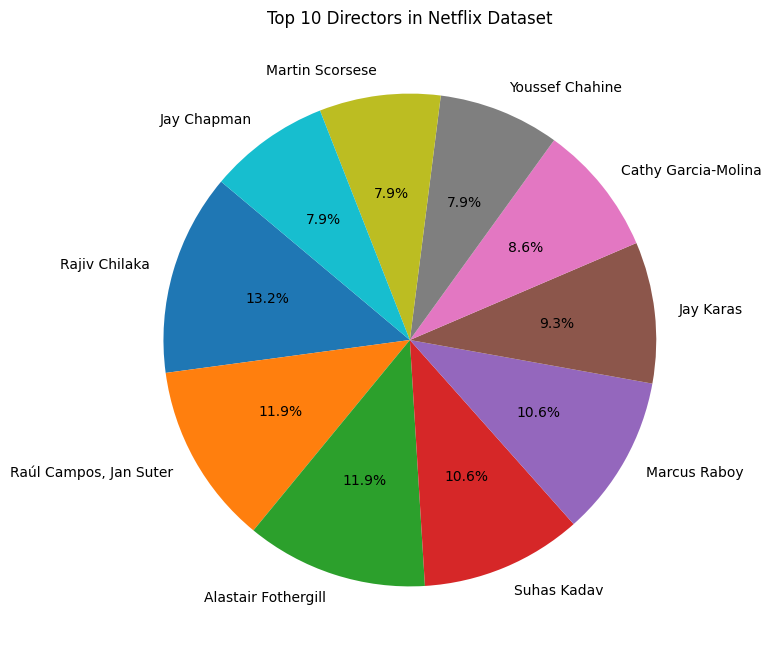

In [5]:
#Pie chart for the top 10 directors skipping the first one which is 'No Data'
top_directors = df['director'].value_counts().head(11).tail(10)
plt.figure(figsize=(8, 8))
plt.pie(top_directors, labels=top_directors.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Directors in Netflix Dataset')
plt.show()

In [6]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [7]:
df['country'].value_counts()

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
                  ... 
Luxembourg           1
Senegal              1
Belarus              1
Puerto Rico          1
Cyprus               1
Name: count, Length: 86, dtype: int64

Let's analyse which type of content is famous in top countries 

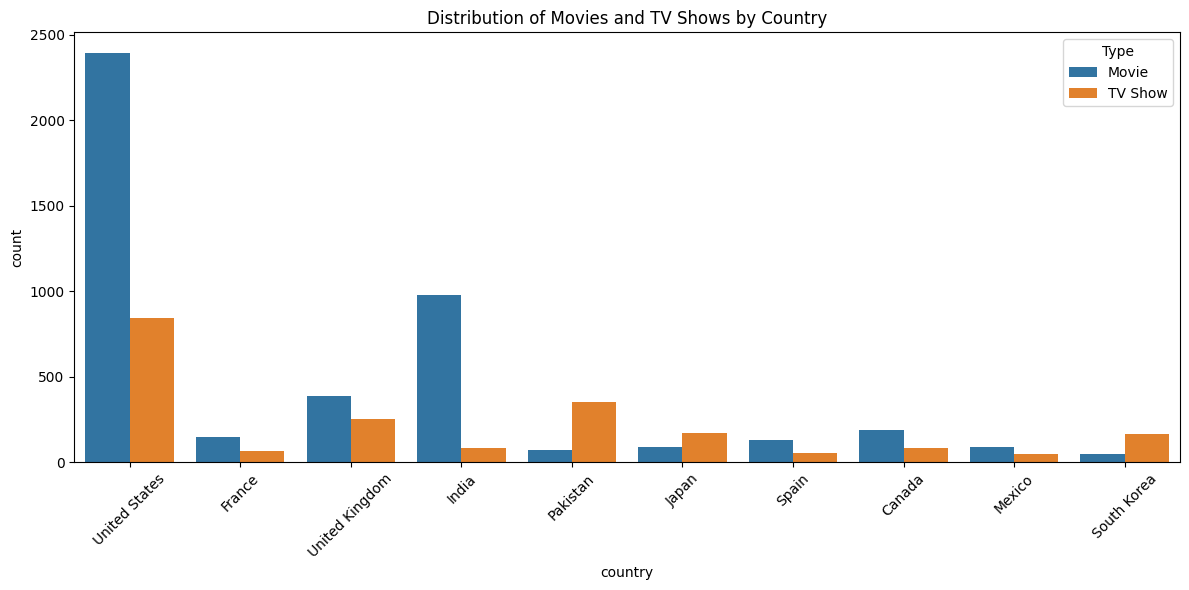

In [8]:
# Type distribution by country for top 10 countries excluding 'Not Given'
top_countries = df['country'].value_counts().head(11).index
df_top_countries = df[df['country'].isin(top_countries) & (df['country'] != 'Not Given')]
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top_countries, x='country', hue='type')
plt.title('Distribution of Movies and TV Shows by Country')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

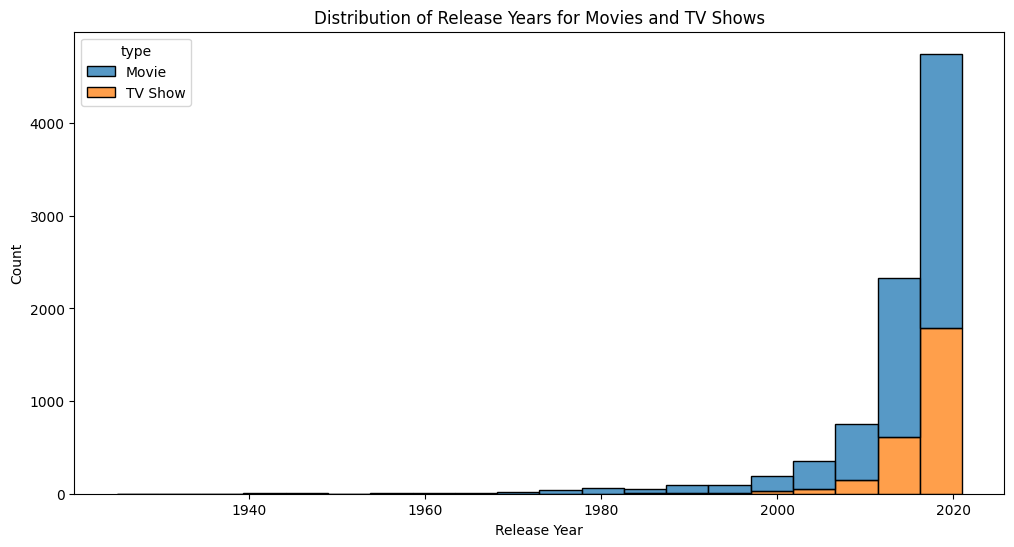

In [9]:
# Let's see the distribution of release years for movies and TV shows
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='release_year', hue='type', multiple='stack', bins=20)
plt.title('Distribution of Release Years for Movies and TV Shows')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()  

## Feature engineering 

Let's extract some useful features 

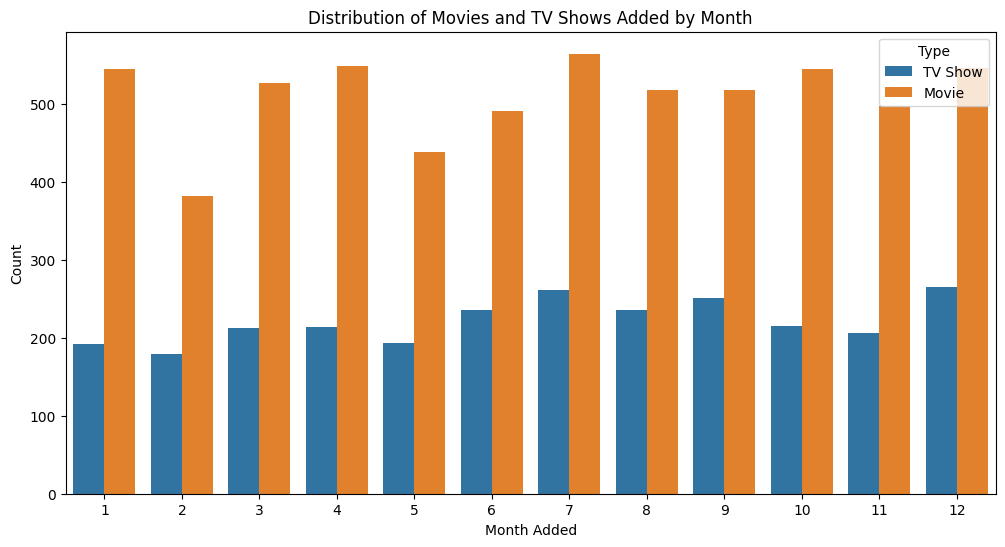

In [12]:
# Let's etract month from the date_added column and see if there is any pattern in the release of movies and TV shows
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['month_added'] = df['date_added'].dt.month
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='month_added', hue='type')
plt.title('Distribution of Movies and TV Shows Added by Month')
plt.xlabel('Month Added')
plt.ylabel('Count')
plt.legend(title='Type')
plt.show()

No such pattern can be seen on the basis of release month, as ther is equla distribution of movie releases 

In [13]:
df['duration'].value_counts()

duration
1 Season      1791
2 Seasons      421
3 Seasons      198
90 min         152
97 min         146
              ... 
191 min          1
17 Seasons       1
10 min           1
312 min          1
11 Seasons       1
Name: count, Length: 220, dtype: int64

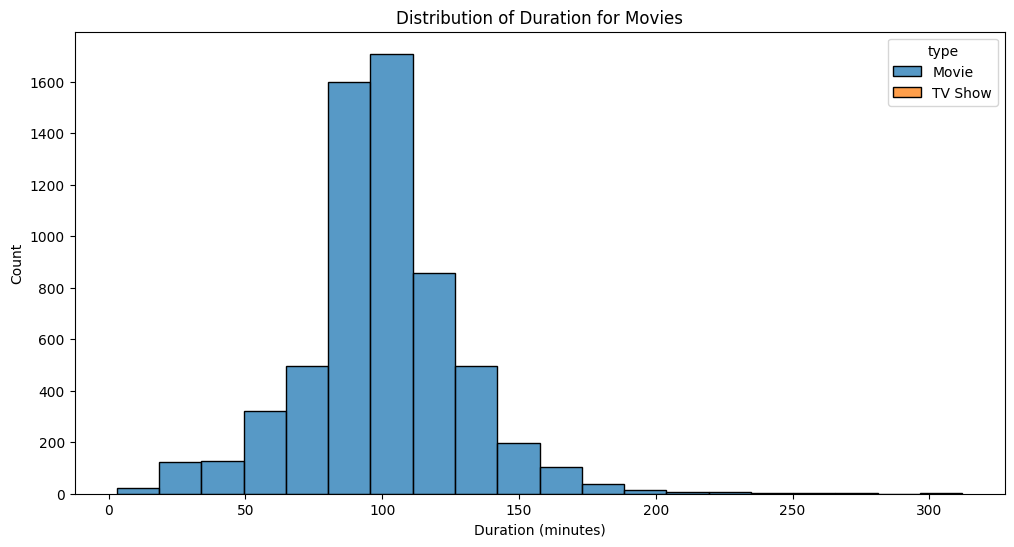

In [20]:
#Let's see the distribution of duration for movies and TV shows separately. For movies, we will consider the duration in minutes and for TV shows, we will consider the number of seasons. Plot it side by side for better comparison.

df['duration_minutes'] = df.apply(lambda x: int(x['duration'].split(' ')[0]) if x['type'] == 'Movie' else np.nan, axis=1)
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='duration_minutes', hue='type', multiple='stack', bins=20)
plt.title('Distribution of Duration for Movies')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()

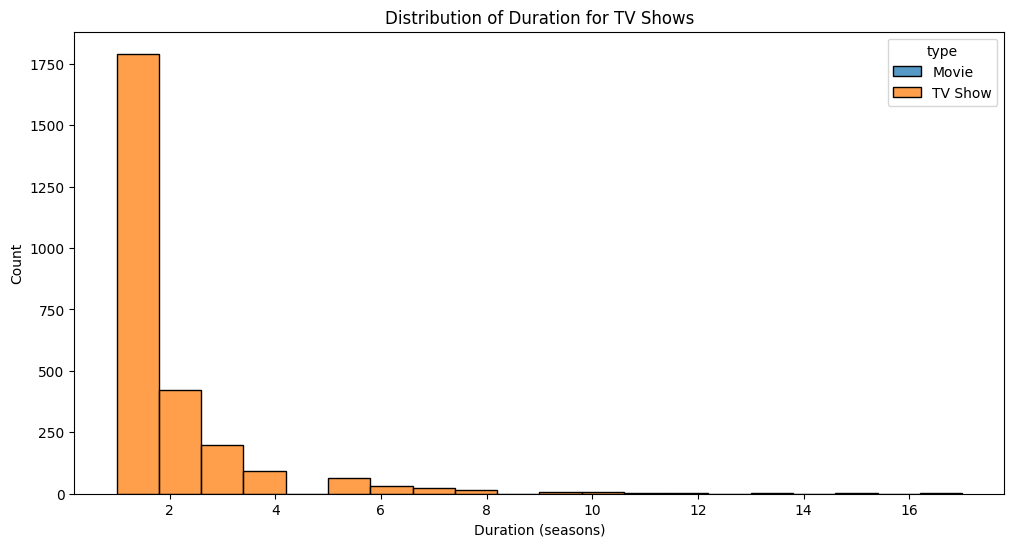

In [19]:
df['duration_seasons'] = df.apply(lambda x: int(x['duration'].split(' ')[0]) if x['type'] == 'TV Show' else np.nan, axis=1) 
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='duration_seasons', hue='type', multiple='stack', bins=20)
plt.title('Distribution of Duration for TV Shows')
plt.xlabel('Duration (seasons)')
plt.ylabel('Count')
plt.show()

In [21]:
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

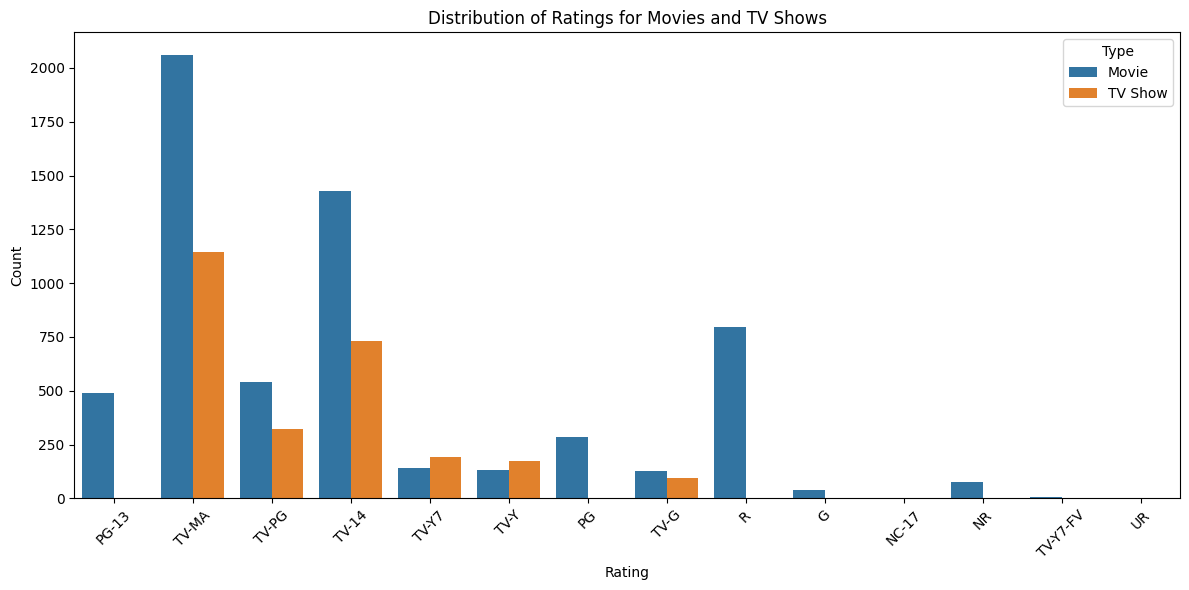

In [22]:
#Let's see the rating distribution for movies and TV shows separately. Plot it side by side for better comparison.
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='rating', hue='type')
plt.title('Distribution of Ratings for Movies and TV Shows')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

We can conclude that TV-MA is the rating widely used for rating movies and tv shows while some of the ratings are dedicatedly used only for movie ratings.

In [23]:
df['listed_in'].value_counts()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Classic & Cult TV, TV Horror, TV Mysteries            1
Crime TV Shows, TV Comedies                           1
Classic & Cult TV, Kids' TV, TV Comedies              1
Classic & Cult TV, TV Sci-Fi & Fantasy                1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Name: count, Length: 513, dtype: int64

In [24]:
df['listed_in'].unique()

<ArrowStringArray>
[                                                'Documentaries',
 'Crime TV Shows, International TV Shows, TV Action & Adventure',
                            'TV Dramas, TV Horror, TV Mysteries',
                            'Children & Family Movies, Comedies',
              'Dramas, Independent Movies, International Movies',
                                  'British TV Shows, Reality TV',
                                              'Comedies, Dramas',
          'Children & Family Movies, Comedies, Music & Musicals',
                                  'Dramas, International Movies',
                    'Children & Family Movies, Music & Musicals',
 ...
                      'British TV Shows, Docuseries, Reality TV',
                    'Anime Series, Crime TV Shows, TV Thrillers',
        'Classic & Cult TV, Kids' TV, Spanish-Language TV Shows',
       'Romantic TV Shows, Spanish-Language TV Shows, TV Dramas',
                            'TV Action & Adventure, 

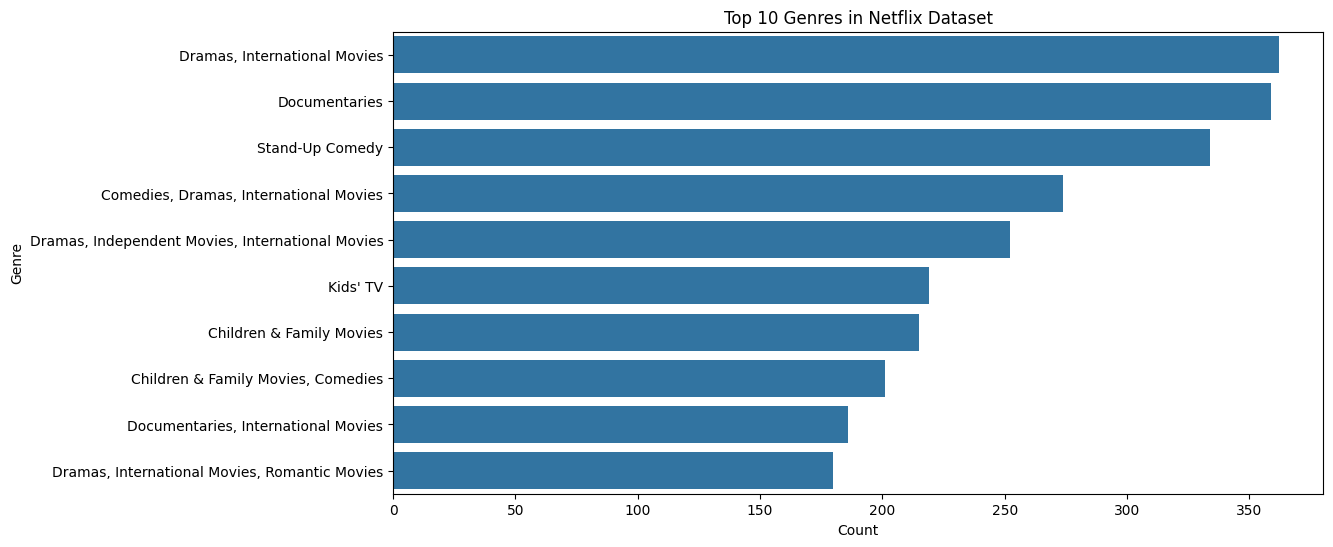

In [25]:
#lets see the top 10 genres in the dataset
top_genres = df['listed_in'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('Top 10 Genres in Netflix Dataset')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()